<a href="https://colab.research.google.com/github/dscamacho333/Data_Science_Course/blob/main/Final_Store_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

In [5]:
store_one_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
store_two_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
store_three_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
store_four_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

In [6]:
store_one_dataframe : pd.DataFrame = pd.read_csv(
    store_one_url,
    sep=','
)
store_two_dataframe : pd.DataFrame = pd.read_csv(
    store_two_url,
    sep=','
)
store_three_dataframe : pd.DataFrame = pd.read_csv(
    store_three_url,
    sep=','
)
store_four_dataframe : pd.DataFrame = pd.read_csv(
    store_four_url,
    sep=','
)

In [7]:
store_one_dataframe['Tienda'] = 'Store 01'
store_two_dataframe['Tienda'] = 'Store 02'
store_three_dataframe['Tienda'] = 'Store 03'
store_four_dataframe['Tienda'] = 'Store 04'

In [8]:
stores : pd.DataFrame = pd.concat(
    [
        store_one_dataframe,
        store_two_dataframe,
        store_three_dataframe,
        store_four_dataframe
    ],
    ignore_index=True
)

In [9]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Tienda                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


## Ingreso total por cada tienda

In [10]:
income_by_store : pd.Series = (
    stores
    .groupby('Tienda')['Precio']
    .sum()
    .round(2)
)

In [11]:
income_by_store

,Precio
Tienda,
Store 01,"1,150,880,400.00"
Store 02,"1,116,343,500.00"
Store 03,"1,098,019,600.00"
Store 04,"1,038,375,700.00"


In [12]:
from matplotlib.axes import Axes
def create_graph(

    object_to_graph,
    graph_type : str,
    title : str,
    x_label : str,
    y_label: str

) -> Axes:

  plt.figure()
  ax = object_to_graph.plot(
      kind=graph_type
  )
  ax.set_title(title)
  ax.set_xlabel(x_label)
  ax.set_ylabel(y_label)

  return ax

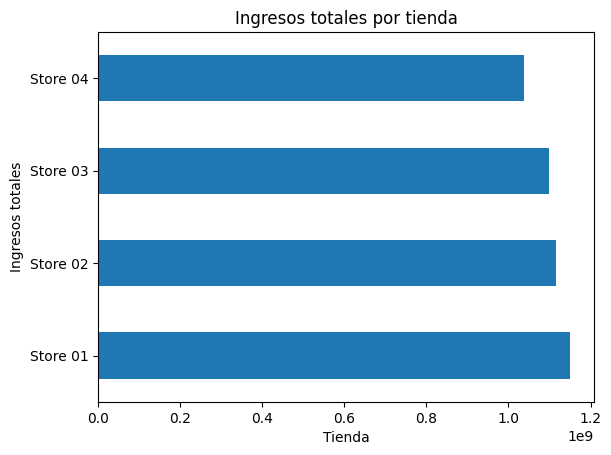

In [13]:
income_by_store_graph : Axes = create_graph(
    income_by_store,
    'barh',
    'Ingresos totales por tienda',
    'Tienda',
    'Ingresos totales'
)

## Ventas por categoría

In [14]:
category_sales = (
    stores
    .groupby(
        [
            'Tienda',
            'Categoría del Producto'
        ]
    )['Producto']
    .count()
    .sort_values(ascending=False)
)

In [15]:
category_sales.loc['Store 01']

,Producto
Categoría del Producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171


In [16]:
category_sales.loc['Store 02']

,Producto
Categoría del Producto,
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275
Instrumentos musicales,224
Libros,197
Artículos para el hogar,181


In [17]:
category_sales.loc['Store 03']

,Producto
Categoría del Producto,
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277
Libros,185
Artículos para el hogar,177
Instrumentos musicales,177


In [18]:
category_sales.loc['Store 04']

,Producto
Categoría del Producto,
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254
Artículos para el hogar,201
Libros,187
Instrumentos musicales,170


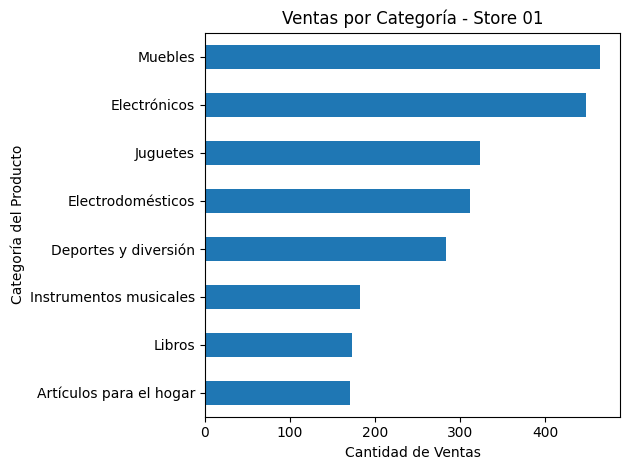

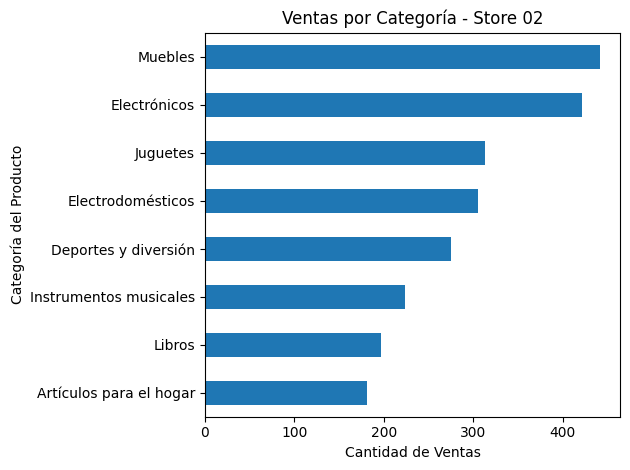

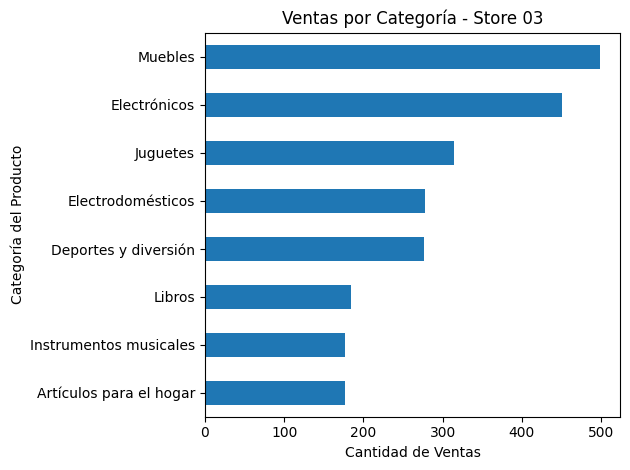

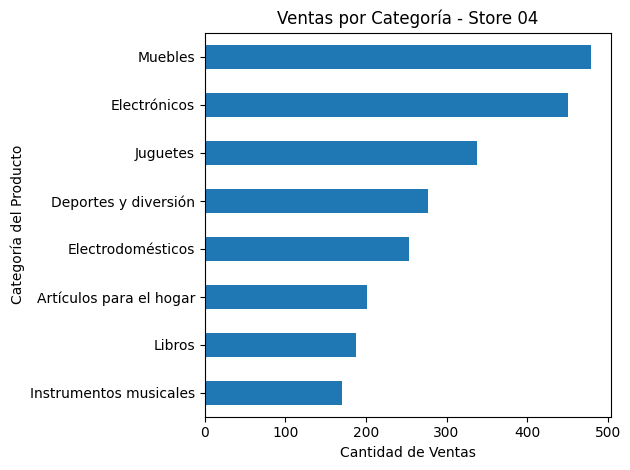

In [19]:
for i in range(1, 5):

    ax = create_graph(
        category_sales.loc[f'Store 0{i}'].sort_values(ascending=True),
        'barh',
        f'Ventas por Categoría - Store 0{i}',
        'Cantidad de Ventas',
        'Categoría del Producto'
    )

    plt.tight_layout()
    plt.show()


## Valoración media por tienda

In [20]:
average_satisfaction_by_store : pd.Series = stores.groupby('Tienda')['Calificación'].mean().sort_values(ascending=False)

In [21]:
average_satisfaction_by_store

,Calificación
Tienda,
Store 03,4.05
Store 02,4.04
Store 04,4.00
Store 01,3.98


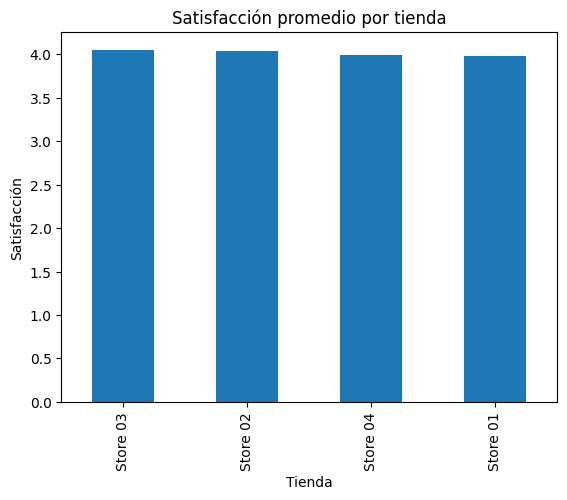

In [22]:
create_graph(
    average_satisfaction_by_store,
    'bar',
    'Satisfacción promedio por tienda',
    'Tienda',
    'Satisfacción'
)

plt.show()

## Most and least sold products

In [23]:
most_sold_products_by_store : pd.Series = (
    stores
    .groupby(['Tienda', 'Producto'])['Producto']
    .count()
    .sort_values(
        ascending=False
    )
)

In [24]:
least_sold_products_by_store : pd.Series = (
    stores
    .groupby(['Tienda', 'Producto'])['Producto']
    .count()
    .sort_values(
        ascending=True
    )
)

In [25]:
most_sold_products_by_store.loc['Store 01'].head()

,Producto
Producto,
TV LED UHD 4K,60
Microondas,60
Armario,60
Secadora de ropa,58
Mesa de noche,56


In [26]:
least_sold_products_by_store.loc['Store 01'].head()

,Producto
Producto,
Auriculares con micrófono,33
Celular ABXY,33
Olla de presión,35
Pandereta,36
Ciencia de datos con Python,39


In [27]:
most_sold_products_by_store.loc['Store 02'].head()

,Producto
Producto,
Iniciando en programación,65
Microondas,62
Batería,61
Pandereta,58
Guitarra acústica,58


In [28]:
least_sold_products_by_store.loc['Store 02'].head()

,Producto
Producto,
Juego de mesa,32
Mesa de comedor,34
Impresora,34
Sillón,35
Auriculares,37


In [29]:
most_sold_products_by_store.loc['Store 03'].head()

,Producto
Producto,
Kit de bancas,57
Cama king,56
Mesa de comedor,56
Mesa de noche,55
Set de ollas,55


In [30]:
least_sold_products_by_store.loc['Store 03'].head()

,Producto
Producto,
Bloques de construcción,35
Set de vasos,36
Microondas,36
Mochila,36
Vaso térmico,38


In [31]:
most_sold_products_by_store.loc['Store 04'].head()

,Producto
Producto,
Cama box,62
Cubertería,59
Cama king,56
Dashboards con Power BI,56
Carrito de control remoto,55


In [32]:
least_sold_products_by_store.loc['Store 04'].head()

,Producto
Producto,
Guitarra eléctrica,33
Armario,34
Guitarra acústica,37
Ciencia de datos con Python,38
Refrigerador,38


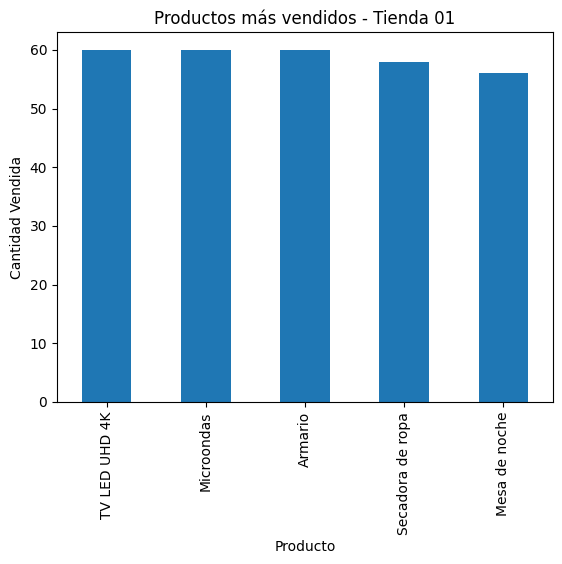

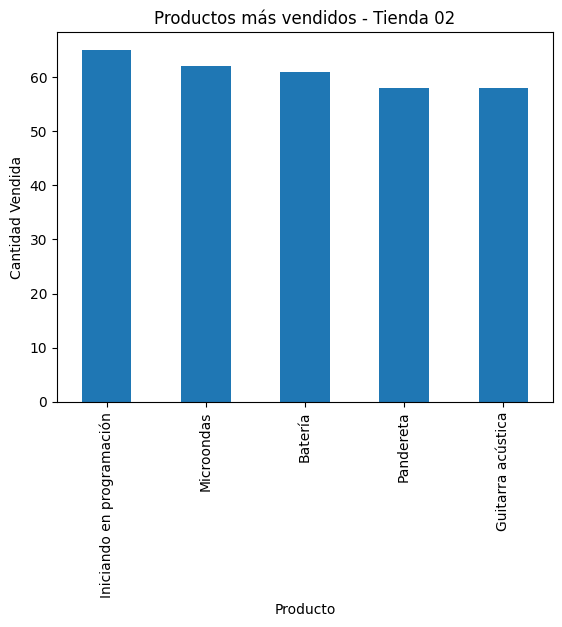

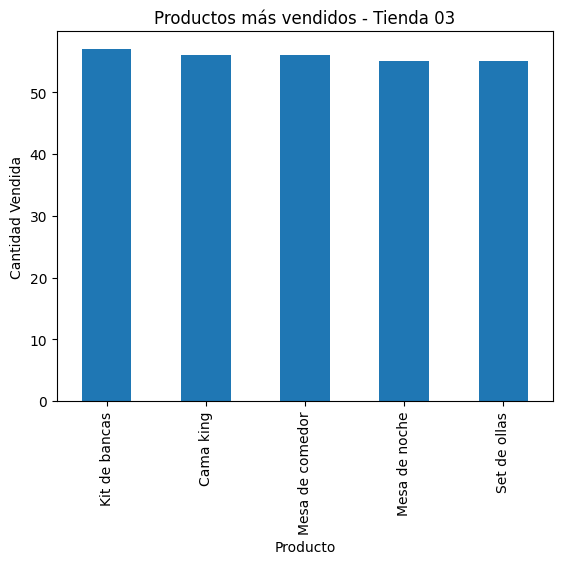

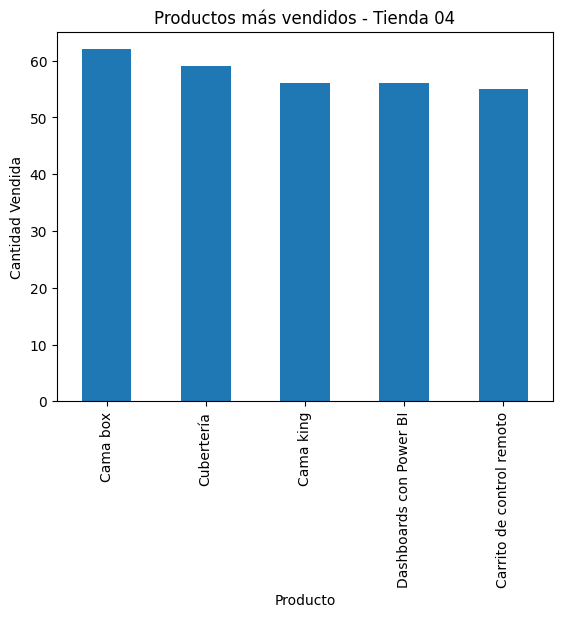

In [33]:
for i in range(1, 5):

  create_graph(
      most_sold_products_by_store.loc[f'Store 0{i}'].head(),
      'bar',
      f'Productos más vendidos - Tienda 0{i}',
      'Producto',
      'Cantidad Vendida'
  )

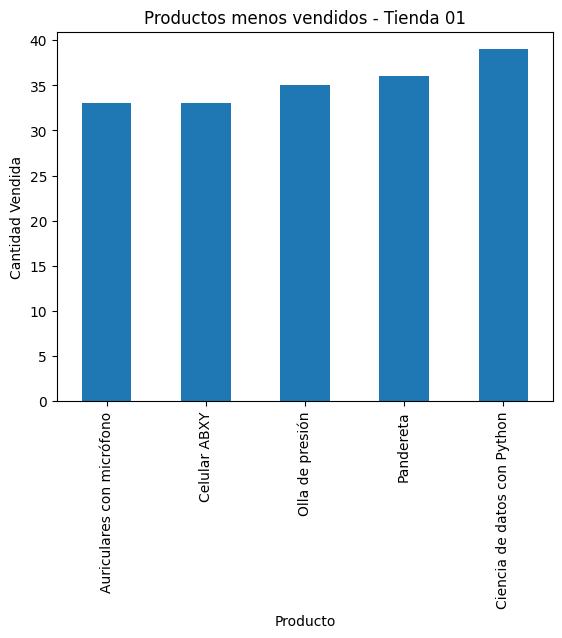

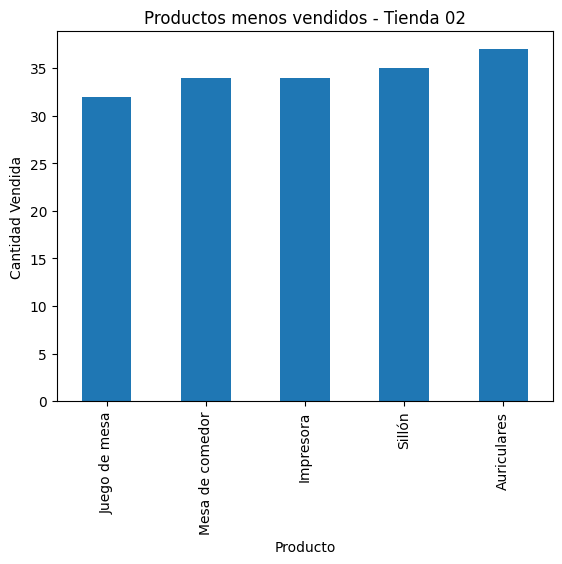

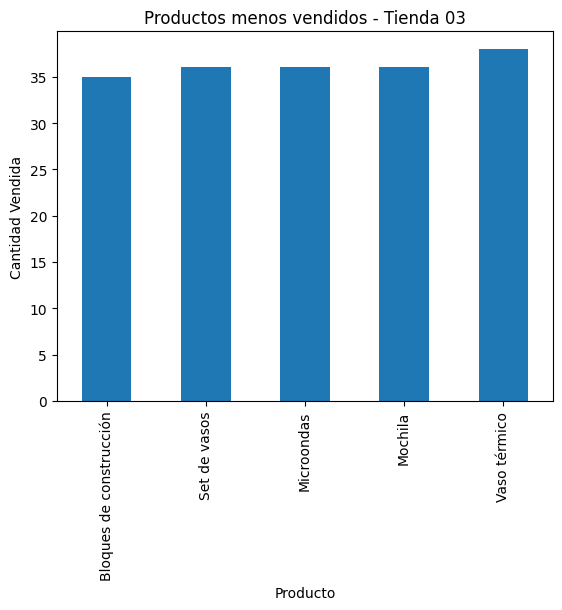

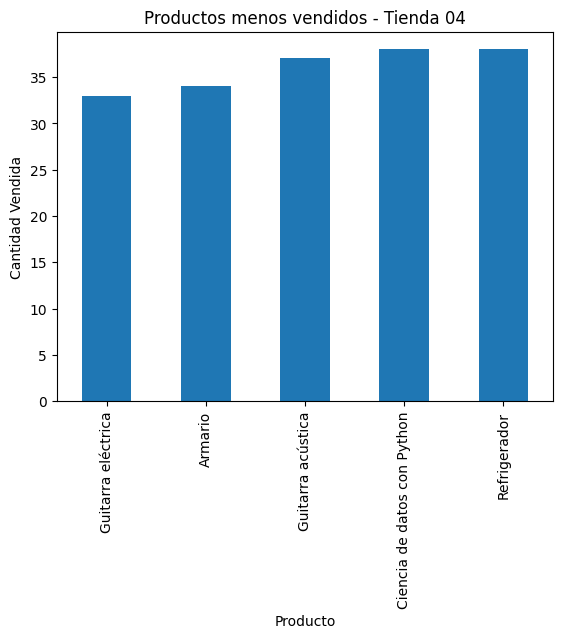

In [34]:
for i in range(1, 5):

  create_graph(
      least_sold_products_by_store.loc[f'Store 0{i}'].head(),
      'bar',
      f'Productos menos vendidos - Tienda 0{i}',
      'Producto',
      'Cantidad Vendida'
  )

## Shipping Average Cost Per Store

In [35]:
shipping_average_cost_per_store : pd.Series = (
    stores
    .groupby('Tienda')['Costo de envío']
    .mean()
)

In [36]:
shipping_average_cost_per_store

,Costo de envío
Tienda,
Store 01,"26,018.61"
Store 02,"25,216.24"
Store 03,"24,805.68"
Store 04,"23,459.46"


<Axes: title={'center': 'Costo Promedio de Envio por Tienda'}, xlabel='Tienda', ylabel='Costo de Envio'>

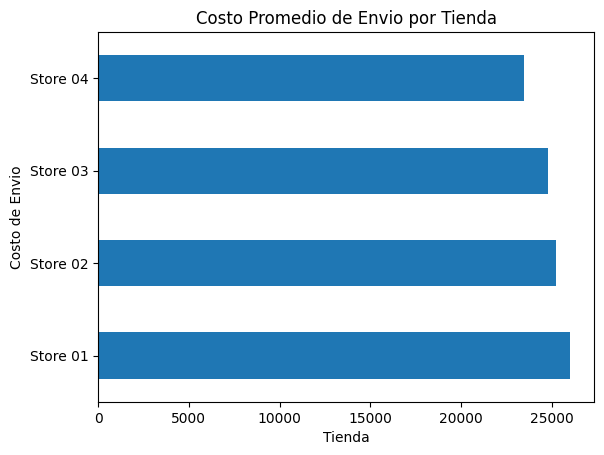

In [37]:
create_graph(
    shipping_average_cost_per_store,
    'barh',
    'Costo Promedio de Envio por Tienda',
    'Tienda',
    'Costo de Envio'
)

## Extra - Geological Sells

In [61]:
def graph_heatmap(
    geo_store,
    index : int
):

  plt.figure()
  plt.hist2d(
    geo_store['lon'],     # eje X
    geo_store['lat'],     # eje Y
    weights=geo_store['Ventas'],
    bins=30,
    cmap='hot'
  )
  plt.colorbar(label='Cantidad de Ventas')
  plt.title(f'Mapa de Calor de Ventas - Store 0{i}')
  plt.xlabel('Longitud')
  plt.ylabel('Latitud')
  plt.tight_layout()
  plt.show()

In [38]:
geological_sells : pd.Series = (
    stores
    .groupby(['Tienda', 'lat', 'lon'])['Producto']
    .count()
    .sort_values(ascending=False)
)

In [43]:
geo_store_01 = geological_sells.loc['Store 01'].reset_index(name='Ventas')

In [44]:
geo_store_01

,lat,lon,Ventas
0,4.61,-74.08,984
1,6.25,-75.56,563
2,3.44,-76.52,283
3,4.81,-75.70,133
4,10.97,-74.78,75
5,10.40,-75.51,53
6,7.89,-72.51,51
7,11.54,-72.91,40
8,11.24,-74.20,32
9,-4.22,-69.94,32


In [54]:
geo_store_02 = geological_sells.loc['Store 02'].reset_index(name='Ventas')

In [55]:
geo_store_02

,lat,lon,Ventas
0,4.61,-74.08,985
1,6.25,-75.56,594
2,3.44,-76.52,222
3,4.81,-75.70,128
4,10.97,-74.78,78
5,10.40,-75.51,70
6,7.89,-72.51,59
7,7.13,-73.12,50
8,11.24,-74.20,40
9,11.54,-72.91,35


In [56]:
geo_store_03 = geological_sells.loc['Store 03'].reset_index(name='Ventas')

In [57]:
geo_store_03

,lat,lon,Ventas
0,4.61,-74.08,983
1,6.25,-75.56,580
2,3.44,-76.52,248
3,4.81,-75.70,134
4,10.97,-74.78,77
5,10.40,-75.51,56
6,7.13,-73.12,50
7,11.24,-74.20,44
8,11.54,-72.91,44
9,7.89,-72.51,44


In [58]:
geo_store_04 = geological_sells.loc['Store 04'].reset_index(name='Ventas')

In [59]:
geo_store_04

,lat,lon,Ventas
0,4.61,-74.08,991
1,6.25,-75.56,577
2,3.44,-76.52,254
3,4.81,-75.70,122
4,10.97,-74.78,80
5,10.40,-75.51,63
6,7.13,-73.12,50
7,11.54,-72.91,44
8,11.24,-74.20,35
9,-4.22,-69.94,35


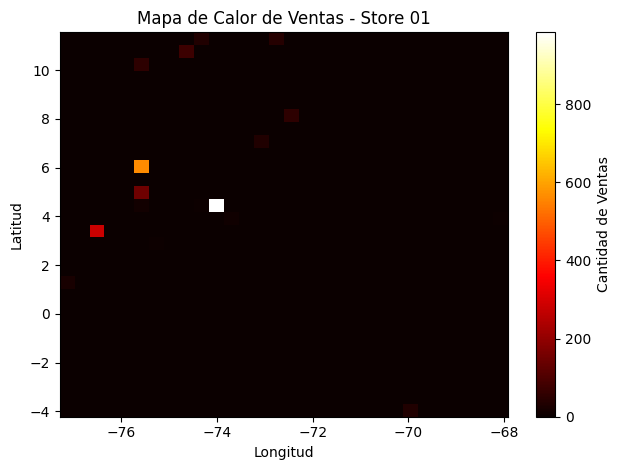

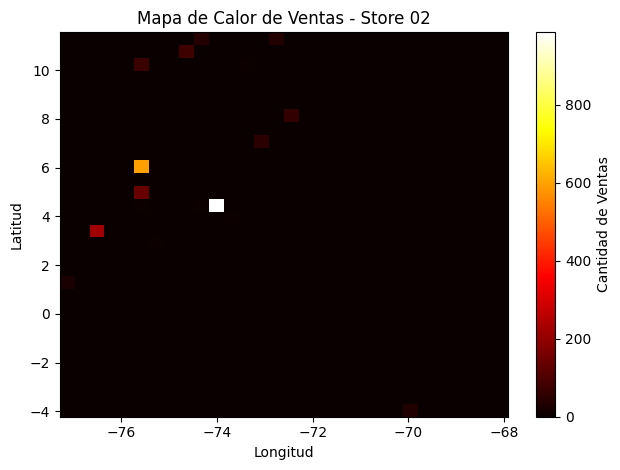

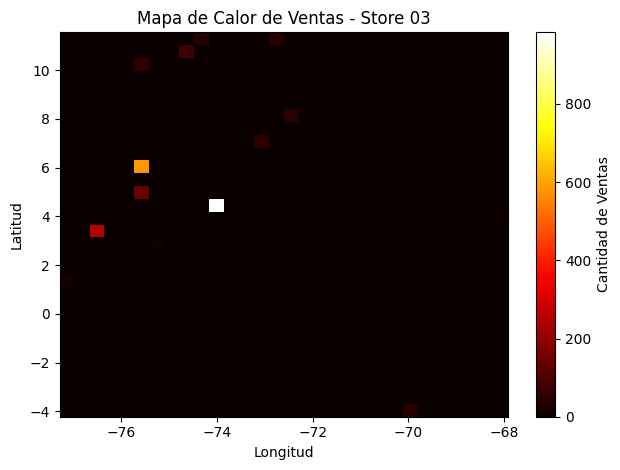

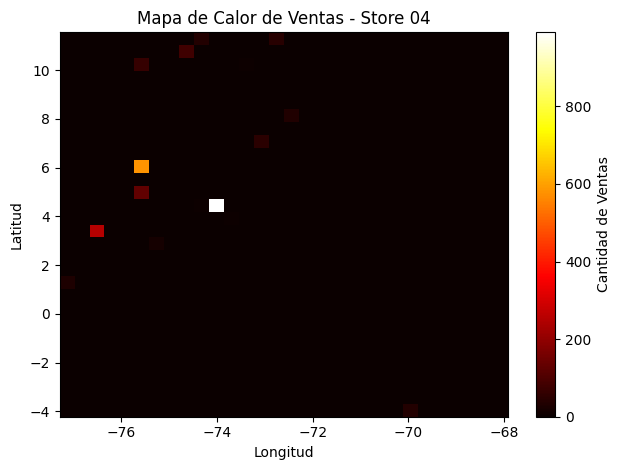

In [63]:
geo_store_list : list = [
    geo_store_01,
    geo_store_02,
    geo_store_03,
    geo_store_04
]

i : int = 1

for geo_store in geo_store_list:

  graph_heatmap(
    geo_store,
    i
  )

  i = i + 1